In [30]:
import json
import math
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap

In [31]:
with open("meteorites.json", "r") as f:
   dati_meteoriti = json.load(f)

In [32]:
print("Numero di meteoriti scaricati:", len(dati_meteoriti))

Numero di meteoriti scaricati: 45716


In [33]:
print("Chiavi disponibili del primo meteorite:")

print(dati_meteoriti[0].keys())

Chiavi disponibili del primo meteorite:
dict_keys(['name', 'id', 'name_type', 'class', 'mass', 'fall', 'year', 'lat', 'long', 'geolocation'])


In [34]:
print("Dati dei primi 5 meteoriti:")

for meteorite in dati_meteoriti[:5]:
    print(meteorite)

Dati dei primi 5 meteoriti:
{'name': 'Aachen', 'id': 1, 'name_type': 'Valid', 'class': 'L5', 'mass': 21.0, 'fall': 'Fell', 'year': 1880.0, 'lat': 50.775, 'long': 6.08333, 'geolocation': '(50.775, 6.08333)'}
{'name': 'Aarhus', 'id': 2, 'name_type': 'Valid', 'class': 'H6', 'mass': 720.0, 'fall': 'Fell', 'year': 1951.0, 'lat': 56.18333, 'long': 10.23333, 'geolocation': '(56.18333, 10.23333)'}
{'name': 'Abee', 'id': 6, 'name_type': 'Valid', 'class': 'EH4', 'mass': 107000.0, 'fall': 'Fell', 'year': 1952.0, 'lat': 54.21667, 'long': -113.0, 'geolocation': '(54.21667, -113.0)'}
{'name': 'Acapulco', 'id': 10, 'name_type': 'Valid', 'class': 'Acapulcoite', 'mass': 1914.0, 'fall': 'Fell', 'year': 1976.0, 'lat': 16.88333, 'long': -99.9, 'geolocation': '(16.88333, -99.9)'}
{'name': 'Achiras', 'id': 370, 'name_type': 'Valid', 'class': 'L6', 'mass': 780.0, 'fall': 'Fell', 'year': 1902.0, 'lat': -33.16667, 'long': -64.95, 'geolocation': '(-33.16667, -64.95)'}


In [35]:
masse = []

for f in dati_meteoriti:
 valori_mas = float(f["mass"])
 if not math.isnan(valori_mas):
    if valori_mas > 0:
        masse.append(valori_mas)

In [36]:
print("Masse trovate:", len(masse))

Masse trovate: 45566


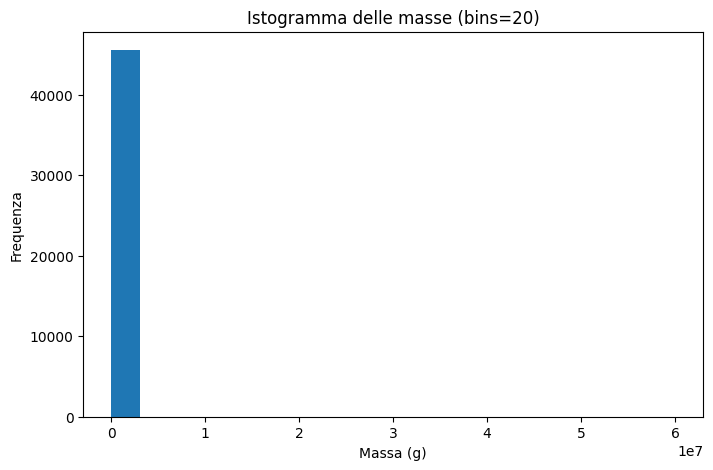

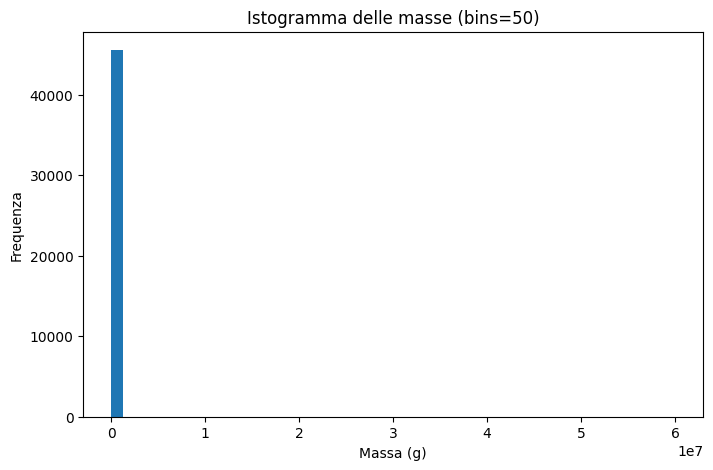

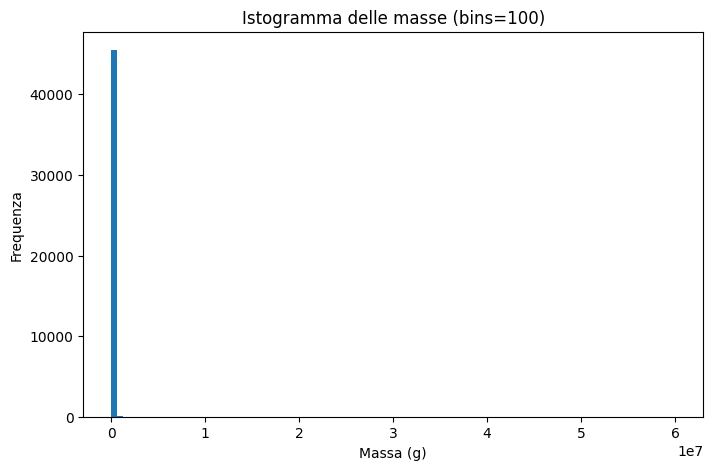

In [37]:
for bins in [20, 50, 100]:
    plt.figure(figsize=(8,5))
    plt.hist(masse, bins=bins)
    plt.title(f"Istogramma delle masse (bins={bins})")
    plt.xlabel("Massa (g)")
    plt.ylabel("Frequenza")
    plt.show()

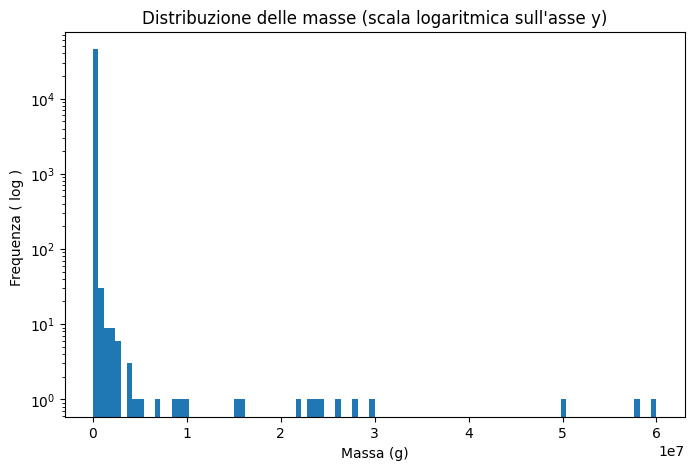

In [38]:
plt.figure(figsize=(8,5))
plt.hist(masse, bins=100)
plt.yscale("log")
plt.title("Distribuzione delle masse (scala logaritmica sull'asse y)")
plt.xlabel("Massa (g)")
plt.ylabel("Frequenza ( log ) ")
plt.show()

In [39]:
coordinate = []

for m in dati_meteoriti:
      lat = float(m["lat"])
      lon = float(m["long"])

      if not math.isnan(lat) and not math.isnan(lon):
             coordinate.append((lat, lon, m["name"]))

In [40]:
mappa = folium.Map(location=[0, 0], zoom_start=2)

In [41]:
for lat, lon, name in coordinate:
    folium.Marker(
        location=[lat, lon],
        popup=name
    ).add_to(mappa)

In [42]:
from folium.plugins import HeatMap

heatmap_dati = [[lat, lon] for lat, lon, name in coordinate]

heatmap_mappa = folium.Map([0, 0], zoom_start=2)

HeatMap(heatmap_dati).add_to(heatmap_mappa)

In [43]:
heatmap_mappa.save ("heatmap.html")

In [44]:
mappa.save ("mappa.html")